# Contour Atlas — 303×317 pair grids (real data)

243 full-year Prescient runs: 9×9 grids over (ω₃₀₃, ω₃₁₇) at three
hydrogen prices ρ_H2 = 1.0 / 1.5 / 2.0 \$/kg (derived bids
B = 20ρ = 20/30/40 \$/MWh), other tiers absent. All metrics are annual
deltas vs the no-PEM base year.

Data: `waves/contour_303x317_{A,B,C}/{design_matrix,objectives}.csv`
(branch `d6`). Script twin: `make_contours.py` (same figures, batch
PDF/PNG output). 2026-09-06.

In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CAMPAIGN = Path.cwd().parent.parent  # analysis/contour_0906 -> campaign
assert (CAMPAIGN / 'waves').is_dir(), CAMPAIGN

SCENARIOS = {'A': 1.0, 'B': 1.5, 'C': 2.0}

METRICS = {
    'delta_curtailment_mwh': dict(label='Δ curtailment [GWh]', scale=1e-3, fmt='%.0f'),
    'delta_load_shed_mwh': dict(label='Δ load shed [MWh]', scale=1.0, fmt='%.0f'),
    'delta_cost_less_synthetic_usd_APPROX': dict(label='Δ gen cost (APPROX) [M$]', scale=1e-6, fmt='%.1f'),
    'delta_reserve_shortfall_mwh': dict(label='Δ reserve shortfall [GWh]', scale=1e-3, fmt='%.0f'),
    'delta_thermal_starts': dict(label='Δ thermal starts [count/yr]', scale=1.0, fmt='%.0f'),
}


def load_wave(tag):
    wdir = CAMPAIGN / 'waves' / f'contour_303x317_{tag}'
    dm = pd.read_csv(wdir / 'design_matrix.csv')
    obj = pd.read_csv(wdir / 'objectives.csv')
    df = dm[['index', 'wind_303_omega', 'wind_317_omega']].merge(obj, on='index')
    assert len(df) == 81, f'{tag}: {len(df)} rows'
    return df


waves = {t: load_wave(t) for t in SCENARIOS}
waves['A'].head(3)

,index,wind_303_omega,wind_317_omega,oat_site,anchor,num_days,start_date,rho_h2,true_curtailment_mwh,load_shed_mwh,...,thermal_starts,synthetic_bid_cost_usd,total_cost_less_synthetic_usd,pem_withheld_mwh_total,h2_kg_total,delta_curtailment_mwh,delta_load_shed_mwh,delta_cost_less_synthetic_usd_APPROX,delta_reserve_shortfall_mwh,delta_thermal_starts
0,1,0.05,0.05000,NaN,False,366,01-01-2020,1.0,1.499726e+06,42015.930320,...,5179,4.800458e+06,5.191565e+08,284113.004433,5.682260e+06,-188849.338199,515.814982,-3.324272e+06,-7170.637600,-4
1,2,0.05,0.16875,NaN,False,366,01-01-2020,1.0,1.350928e+06,38989.092506,...,4921,8.414759e+06,5.166668e+08,545163.499431,1.090327e+07,-337647.923134,-2511.022832,-5.813953e+06,-20110.603187,-262
2,3,0.05,0.28750,NaN,False,366,01-01-2020,1.0,1.234519e+06,37865.744734,...,4837,1.123262e+07,5.152566e+08,770035.014815,1.540070e+07,-454056.567097,-3634.370604,-7.224173e+06,-24396.547454,-346


## Plot helpers

Diverging scale centered at 0 (blue = improvement vs base, red = worse);
grid nodes shown as dots — the data is 9×9, the shading between nodes is
interpolation; ★ marks the best (most negative) measured cell.

In [2]:
def pivot(df, col):
    p = df.pivot(index='wind_317_omega', columns='wind_303_omega', values=col)
    return p.columns.values, p.index.values, p.values


def draw_panel(ax, x, y, Z, norm, cmap, fmt, title):
    pm = ax.pcolormesh(x, y, Z, norm=norm, cmap=cmap, shading='gouraud')
    cs = ax.contour(x, y, Z, levels=8, colors='k', linewidths=0.5, alpha=0.6)
    ax.clabel(cs, fontsize=6, fmt=fmt)
    xx, yy = np.meshgrid(x, y)
    ax.plot(xx.ravel(), yy.ravel(), '.', color='k', ms=1.5, alpha=0.35)
    i, j = np.unravel_index(np.nanargmin(Z), Z.shape)
    ax.plot(x[j], y[i], '*', color='w', mec='k', ms=13, mew=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(r'$\omega_{303}$')
    return pm


def sym_norm(*arrays):
    m = max(np.nanmax(np.abs(a)) for a in arrays)
    return matplotlib.colors.TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)


def metric_panels(col, mi):
    grids = {}
    for t, df in waves.items():
        x, y, Z = pivot(df, col)
        grids[t] = Z * mi['scale']
    norm = sym_norm(*grids.values())
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)
    for ax, (t, rho) in zip(axes, SCENARIOS.items()):
        pm = draw_panel(ax, x, y, grids[t], norm, 'RdBu_r', mi['fmt'],
                        rf'{t}: $\rho_{{H2}}$ = {rho} \$/kg (B = {int(20 * rho)} \$/MWh)')
    axes[0].set_ylabel(r'$\omega_{317}$')
    cb = fig.colorbar(pm, ax=axes, shrink=0.9, pad=0.015)
    cb.set_label(mi['label'])
    fig.suptitle(f"{mi['label']} (blue = improvement vs base; ★ = grid best)", fontsize=11)
    plt.show()
    dBA, dCA = grids['B'] - grids['A'], grids['C'] - grids['A']
    norm = sym_norm(dBA, dCA)
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8), sharey=True)
    for ax, (Z, ttl) in zip(axes, [(dBA, 'B − A  (1.5 vs 1.0 $/kg)'),
                                   (dCA, 'C − A  (2.0 vs 1.0 $/kg)')]):
        pm = draw_panel(ax, x, y, Z, norm, 'PuOr_r', mi['fmt'], ttl)
    axes[0].set_ylabel(r'$\omega_{317}$')
    cb = fig.colorbar(pm, ax=axes, shrink=0.9, pad=0.02)
    cb.set_label(f"shift in {mi['label']}")
    fig.suptitle(f"H2-price shift of {mi['label']}", fontsize=11)
    plt.show()

## Δ generation cost (APPROX) — the sign flip

At ρ = 1.0 the whole surface saves (up to −32 M\$/yr); at ρ ≥ 1.5 it is
uniformly positive (up to +50 M\$/yr at C): the higher bid withholds wind
the grid would buy below 30–40 \$/MWh and thermal backfills. APPROX caveat
(base-nuclear fuel asymmetry) applies.

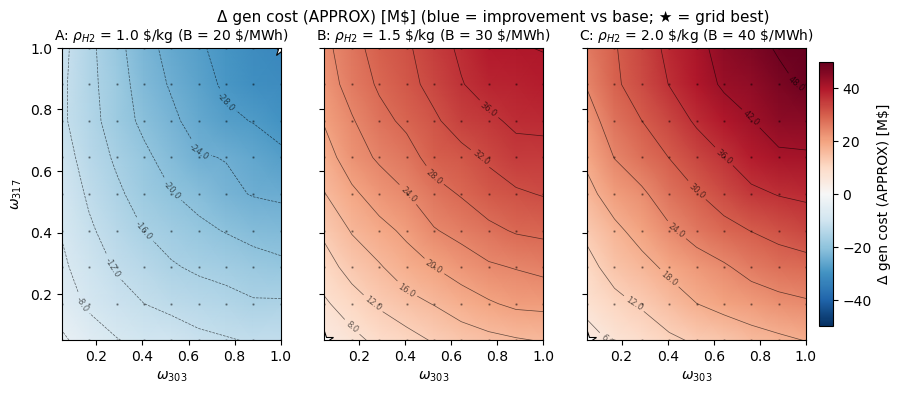

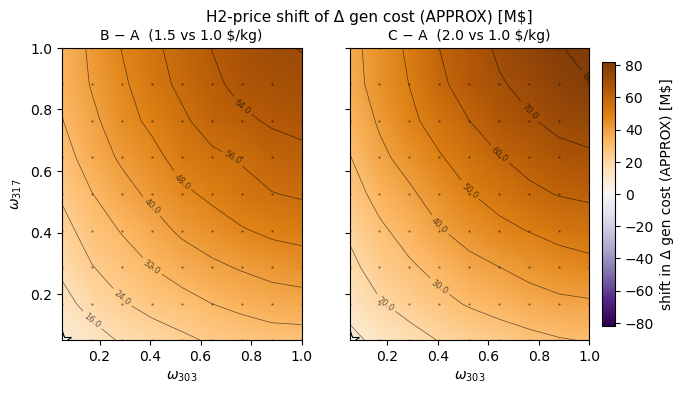

In [3]:
metric_panels('delta_cost_less_synthetic_usd_APPROX',
              METRICS['delta_cost_less_synthetic_usd_APPROX'])

## Δ curtailment — size-driven, price-insensitive

Three nearly identical surfaces (curtailment-hours clear at LMP ≤ 1, so
any bid ≥ ~1 captures them equally); saturation along the diagonal — the
two sites are substitutes.

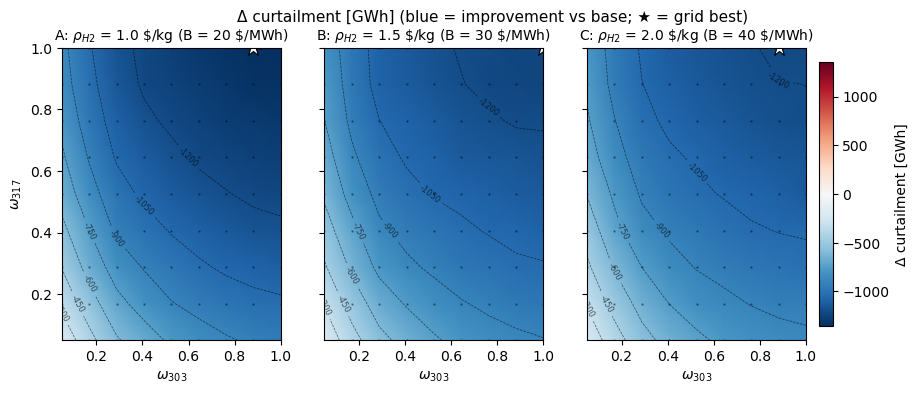

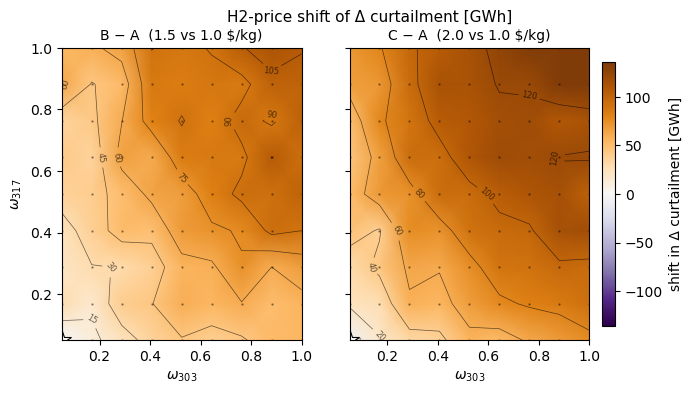

In [4]:
metric_panels('delta_curtailment_mwh', METRICS['delta_curtailment_mwh'])

## Δ load shed — the conservative-DA reliability dividend

Improves with both ω and ρ (−12 / −34 / −39 GWh of a 41.5 GWh base).
Noise floor ±3 GWh: interior wiggles below that are not features.

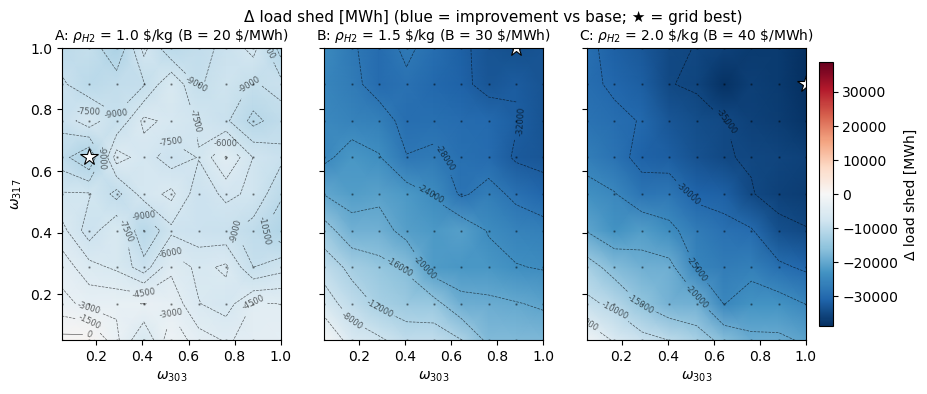

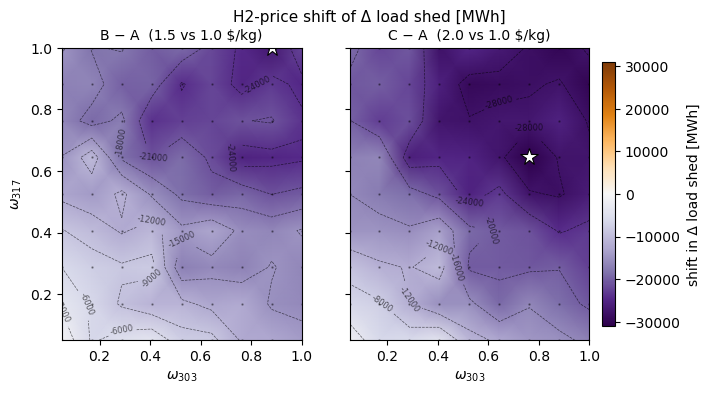

In [5]:
metric_panels('delta_load_shed_mwh', METRICS['delta_load_shed_mwh'])

## Δ reserve shortfall

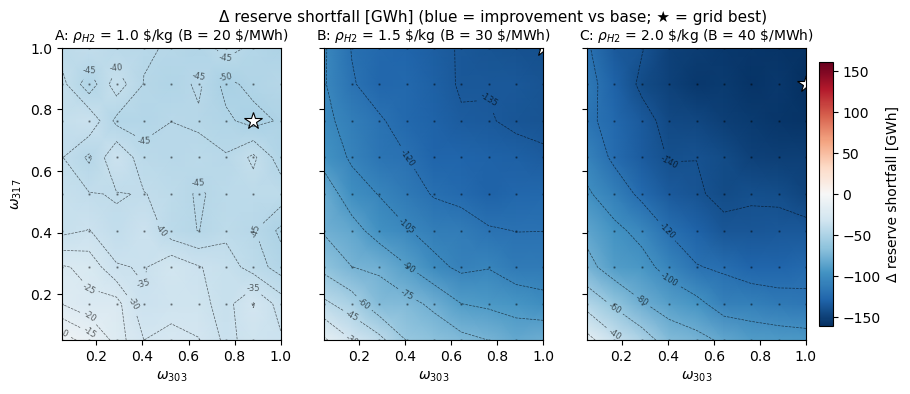

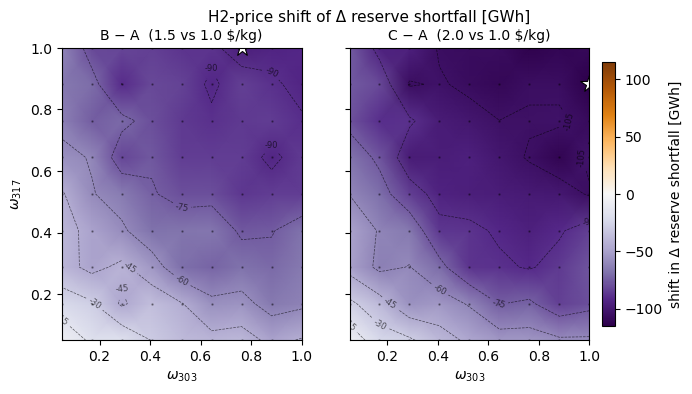

In [6]:
metric_panels('delta_reserve_shortfall_mwh', METRICS['delta_reserve_shortfall_mwh'])

## Δ thermal starts

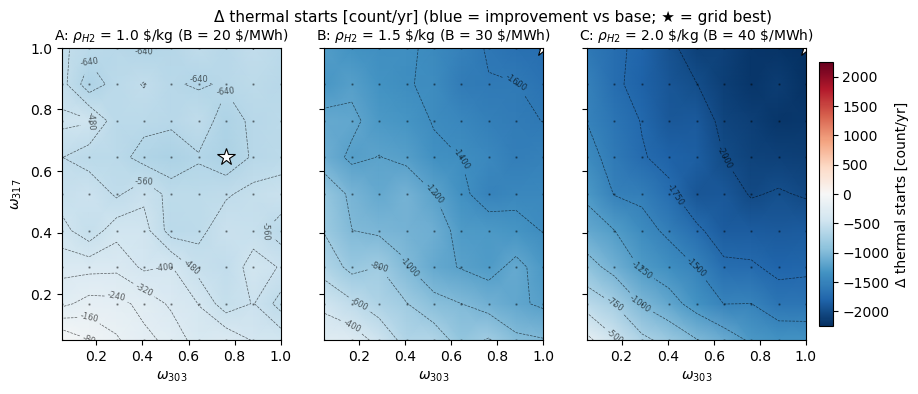

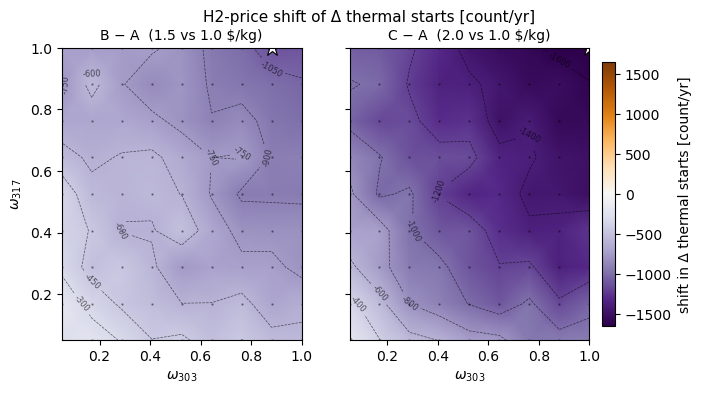

In [7]:
metric_panels('delta_thermal_starts', METRICS['delta_thermal_starts'])

## H2 production (sequential scale — magnitude, not polarity)

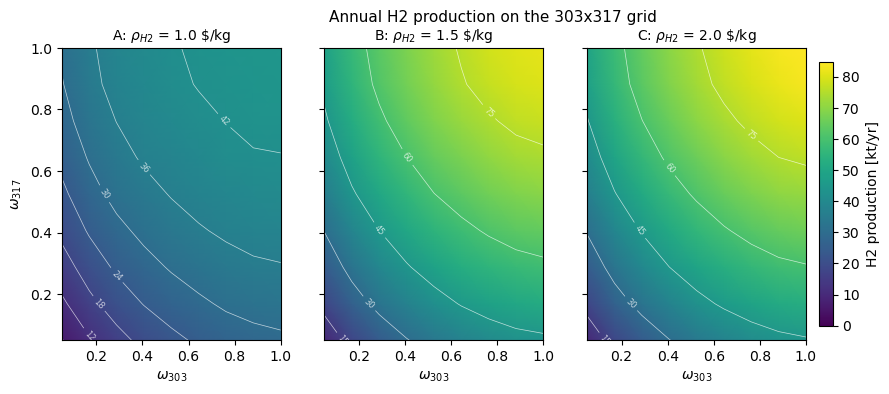

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)
vmax = max(np.nanmax(pivot(df, 'h2_kg_total')[2]) for df in waves.values()) / 1e6
for ax, (t, rho) in zip(axes, SCENARIOS.items()):
    x, y, Z = pivot(waves[t], 'h2_kg_total')
    Z = Z / 1e6
    pm = ax.pcolormesh(x, y, Z, vmin=0, vmax=vmax, cmap='viridis', shading='gouraud')
    cs = ax.contour(x, y, Z, levels=6, colors='w', linewidths=0.5, alpha=0.7)
    ax.clabel(cs, fontsize=6, fmt='%.0f')
    ax.set_title(rf'{t}: $\rho_{{H2}}$ = {rho} \$/kg', fontsize=10)
    ax.set_xlabel(r'$\omega_{303}$')
axes[0].set_ylabel(r'$\omega_{317}$')
cb = fig.colorbar(pm, ax=axes, shrink=0.9, pad=0.015)
cb.set_label('H2 production [kt/yr]')
fig.suptitle('Annual H2 production on the 303x317 grid', fontsize=11)
plt.show()

## Best grid point per metric per scenario

In [9]:
rows = []
for col, mi in METRICS.items():
    for t, df in waves.items():
        r = df.loc[df[col].idxmin()]
        rows.append(dict(metric=mi['label'], scenario=t,
                         best=round(r[col] * mi['scale'], 1),
                         w303=round(r.wind_303_omega, 3),
                         w317=round(r.wind_317_omega, 3)))
pd.DataFrame(rows).pivot(index='metric', columns='scenario',
                         values=['best', 'w303', 'w317'])

best                     w303                \
scenario                           A        B        C      A      B      C   
metric                                                                        
Δ curtailment [GWh]          -1351.1  -1243.7  -1217.8  0.881  1.000  0.881   
Δ gen cost (APPROX) [M$]       -32.2      4.5      4.0  1.000  0.050  0.050   
Δ load shed [MWh]           -12109.3 -33870.4 -38579.9  0.169  0.881  1.000   
Δ reserve shortfall [GWh]      -52.1   -141.6   -160.5  0.881  1.000  1.000   
Δ thermal starts [count/yr]   -706.0  -1712.0  -2245.0  0.762  1.000  1.000   

                              w317               
scenario                         A     B      C  
metric                                           
Δ curtailment [GWh]          1.000  1.00  1.000  
Δ gen cost (APPROX) [M$]     1.000  0.05  0.050  
Δ load shed [MWh]            0.644  1.00  0.881  
Δ reserve shortfall [GWh]    0.762  1.00  0.881  
Δ thermal starts [count/yr]  0.644  1.00  1.000